# HI, H₂ and Cold Gas Mass Functions

Computes and compares the z = 0 galaxy mass functions for:
- **HI** (atomic hydrogen): M_HI = (1 − f_H₂) × M_cold
- **H₂** (molecular hydrogen): M_H₂ = f_H₂ × M_cold  
- **Total cold gas**: M_cold (from `ColdGas` field)

All three are L-GALAXIES outputs — no PCA equivalent exists for gas masses.

**Observational references (HI only)**
| Reference | Survey | H₀ | log M* | α | φ* |
|-----------|--------|-----|--------|---|----|
| Jones et al. 2018 | ALFALFA 100% | 70 | 9.94 | −1.25 | 4.5×10⁻³ Mpc⁻³ dex⁻¹ |
| Zwaan et al. 2005 | HIPASS | 75 | 9.79 | −1.37 | 6.0×10⁻³ Mpc⁻³ dex⁻¹ |

Both references are converted to h = 0.673 (simulation cosmology): φ* × h³, log M* corrected for H₀ difference.

**Note on M_HI definition**: L-GALAXIES `H2fraction` is the molecular fraction of total cold gas.  
M_HI = (1 − f_H₂) × M_cold includes He and metals (~27% of cold gas by mass). For a rigorous  
comparison to 21 cm observations (atomic H only) this overestimates M_HI by ~0.15 dex.  
This is the standard convention in SAM literature and is noted on the plots.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR    = Path('.').resolve()                    # .../GALsPeCtrA/notebooks
GALSPECTRA_ROOT = NOTEBOOK_DIR.parent                    # .../GALsPeCtrA
LGAL_ROOT       = GALSPECTRA_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
SAMPLE_FILE     = LGAL_ROOT / 'output' / 'samples' / \
                  'Planck_Mil-I_snapshots_default_test3_z0.00-0.00_All.npy'

# ── cosmology & volume ──────────────────────────────────────────────────────
HUB_H         = 0.673
BOX_SIZE_MPCh = 480.279
N_TOTAL_FILES = 512
N_FILES_USED  = 1
V_EFF         = BOX_SIZE_MPCh**3 * N_FILES_USED / N_TOTAL_FILES

# ── mass-function bins ──────────────────────────────────────────────────────
LOGM_BINS = np.arange(7.0, 11.51, 0.25)
N_MIN     = 5

# ── ALFALFA / HIPASS references (converted to h=0.673) ─────────────────────
# phi* [physical Mpc^-3 dex^-1] × h^3  →  (Mpc/h)^-3 dex^-1
# logM* corrected for H0 ratio: M_HI ∝ H0^-2
REFERENCES = {
    'ALFALFA (Jones+18)': dict(
        logMstar = 9.94 + 2*np.log10(70.0  / (HUB_H*100)),
        alpha    = -1.25,
        phi_star = 4.5e-3 * HUB_H**3,
        color    = 'dimgray',
        ls       = '-',
        zorder   = 3,
    ),
    'HIPASS (Zwaan+05)': dict(
        logMstar = 9.79 + 2*np.log10(75.0  / (HUB_H*100)),
        alpha    = -1.37,
        phi_star = 6.0e-3 * HUB_H**3,
        color    = 'silver',
        ls       = '--',
        zorder   = 2,
    ),
}

print(f'Effective volume : {V_EFF:.3e} (Mpc/h)^3')
print(f'                 : {V_EFF/HUB_H**3:.3e} Mpc^3  (physical)')
print(f'log10 M bins     : {LOGM_BINS[0]:.1f} - {LOGM_BINS[-1]:.1f},  step {LOGM_BINS[1]-LOGM_BINS[0]:.2f} dex  ({len(LOGM_BINS)-1} bins)')
print(f'Sample file found: {SAMPLE_FILE.exists()}')
print()
print('Reference Schechter parameters (h=0.673 convention):')
for name, p in REFERENCES.items():
    print(f'  {name}: logM* = {p["logMstar"]:.3f}, alpha = {p["alpha"]:.2f}, phi* = {p["phi_star"]:.4e} (Mpc/h)^-3 dex^-1')

Effective volume : 2.164e+05 (Mpc/h)^3
                 : 7.098e+05 Mpc^3  (physical)
log10 M bins     : 7.0 - 11.5,  step 0.25 dex  (18 bins)
Sample file found: True

Reference Schechter parameters (h=0.673 convention):
  ALFALFA (Jones+18): logM* = 9.974, alpha = -1.25, phi* = 1.3717e-03 (Mpc/h)^-3 dex^-1
  HIPASS (Zwaan+05): logM* = 9.884, alpha = -1.37, phi* = 1.8289e-03 (Mpc/h)^-3 dex^-1


## 1. Load sample and compute gas masses

In [2]:
sample = np.load(SAMPLE_FILE)
N_GAL  = len(sample)

# units: ColdGas, H2fraction already in physical Msun (unit-converted sample)
cold_gas = np.maximum(sample['ColdGas'].astype(np.float64), 0.0)
h2frac   = np.clip(sample['H2fraction'].astype(np.float64), 0.0, 1.0)
gal_type = sample['Type'].astype(int)

M_HI   = (1.0 - h2frac) * cold_gas   # Msun  (SAM convention: includes He + metals)
M_H2   = h2frac          * cold_gas   # Msun
M_cold = cold_gas                     # Msun

# Minimum meaningful mass: below 10^6 Msun the galaxy is below any observable threshold
_M_MIN = 1e6

mask_HI   = M_HI   >= _M_MIN
mask_H2   = M_H2   >= _M_MIN
mask_cold = M_cold >= _M_MIN

# np.log10 on np.where(mask, M, 1.0) avoids log10(0) warnings from unevaluated branch
logM_HI   = np.where(mask_HI,   np.log10(np.where(mask_HI,   M_HI,   1.0)), np.nan)
logM_H2   = np.where(mask_H2,   np.log10(np.where(mask_H2,   M_H2,   1.0)), np.nan)
logM_cold = np.where(mask_cold, np.log10(np.where(mask_cold, M_cold, 1.0)), np.nan)

print(f'Total galaxies  : {N_GAL:,}')
print(f'  Type-0 (central)  : {(gal_type==0).sum():,}')
print(f'  Type-1 (satellite): {(gal_type==1).sum():,}')
print(f'  Type-2 (orphan)   : {(gal_type==2).sum():,}')
print()
print(f'M_HI  >= 10^6 Msun : {mask_HI.sum():,}   log10 range: {np.nanmin(logM_HI):.2f} - {np.nanmax(logM_HI):.2f}  (median {np.nanmedian(logM_HI):.2f})')
print(f'M_H2  >= 10^6 Msun : {mask_H2.sum():,}   log10 range: {np.nanmin(logM_H2):.2f} - {np.nanmax(logM_H2):.2f}  (median {np.nanmedian(logM_H2):.2f})')
print(f'M_cold>= 10^6 Msun : {mask_cold.sum():,}   log10 range: {np.nanmin(logM_cold):.2f} - {np.nanmax(logM_cold):.2f}  (median {np.nanmedian(logM_cold):.2f})')

Total galaxies  : 11,328
  Type-0 (central)  : 6,419
  Type-1 (satellite): 2,468
  Type-2 (orphan)   : 2,441

M_HI  >= 10^6 Msun : 11,032   log10 range: 6.00 - 10.77  (median 9.20)
M_H2  >= 10^6 Msun : 10,367   log10 range: 6.01 - 10.74  (median 8.40)
M_cold>= 10^6 Msun : 11,032   log10 range: 6.00 - 11.04  (median 9.26)


## 2. Mass function utilities

In [3]:
def compute_mf(logM_arr, V_eff_h3, logm_bins):
    """Volume-limited mass function in (Mpc/h)^-3 dex^-1."""
    valid = logM_arr[np.isfinite(logM_arr)]
    counts, edges = np.histogram(valid, bins=logm_bins)
    dlogM   = np.diff(edges)
    centres = 0.5 * (edges[:-1] + edges[1:])
    phi     = counts / (V_eff_h3 * dlogM)
    err     = np.sqrt(np.maximum(counts, 1)) / (V_eff_h3 * dlogM)
    return centres, phi, err, counts


def schechter_mf(logM, ref):
    """Schechter MF in log10(M) space: phi(logM) = ln10 * phi* * (M/M*)^(a+1) * exp(-M/M*)."""
    x = 10.0 ** (logM - ref['logMstar'])
    return np.log(10) * ref['phi_star'] * x**(ref['alpha'] + 1) * np.exp(-x)


# ── compute all mass functions ───────────────────────────────────────────────
mf = {}
mf['HI']   = compute_mf(logM_HI,   V_EFF, LOGM_BINS)
mf['H2']   = compute_mf(logM_H2,   V_EFF, LOGM_BINS)
mf['cold'] = compute_mf(logM_cold, V_EFF, LOGM_BINS)

# ── by galaxy type (HI only) ─────────────────────────────────────────────────
mf_type = {t: compute_mf(logM_HI[gal_type == t], V_EFF, LOGM_BINS) for t in [0, 1, 2]}

# sanity: Schechter at M* = ln10 * phi* / e
ref_alfalfa = REFERENCES['ALFALFA (Jones+18)']
phi_at_Mstar = schechter_mf(ref_alfalfa['logMstar'], ref_alfalfa)
expected     = np.log(10) * ref_alfalfa['phi_star'] / np.e
print(f"Schechter at M* (ALFALFA): {phi_at_Mstar:.4e}  (expected ln10*phi*/e = {expected:.4e})  {'OK' if abs(phi_at_Mstar/expected - 1) < 1e-6 else 'MISMATCH'}")
print()
print(f'HI mass function N per bin at representative masses:')
c_hi, _, _, n_hi = mf['HI']
for logm_target in [8.0, 9.0, 9.5, 10.0, 10.5]:
    idx = np.argmin(np.abs(c_hi - logm_target))
    print(f'  log10 M = {c_hi[idx]:.2f}: N = {n_hi[idx]}')

Schechter at M* (ALFALFA): 1.1619e-03  (expected ln10*phi*/e = 1.1619e-03)  OK

HI mass function N per bin at representative masses:
  log10 M = 7.88: N = 293
  log10 M = 8.88: N = 1215
  log10 M = 9.38: N = 1946
  log10 M = 9.88: N = 991
  log10 M = 10.38: N = 132


## 3. Main figure: HI mass function

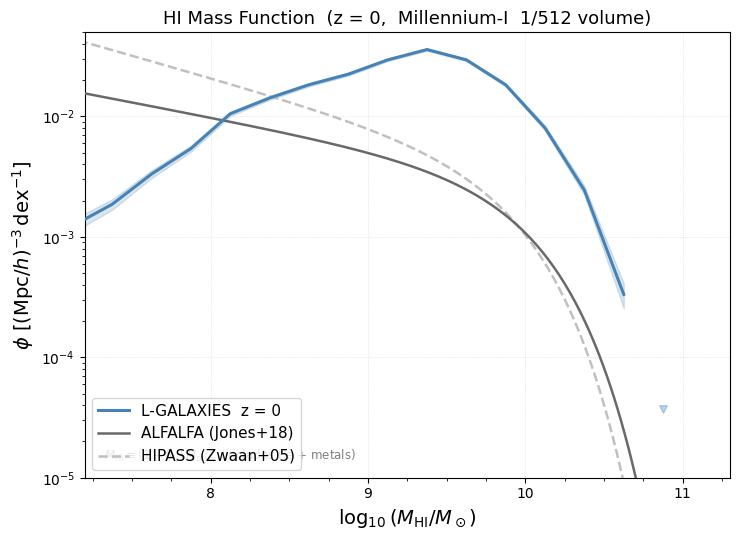

In [4]:
centres, phi, err, counts = mf['HI']
good   = counts >= N_MIN
sparse = ~good & (phi > 0)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# ── simulation HIMF ──────────────────────────────────────────────────────────
ax.fill_between(centres[good], phi[good] - err[good], phi[good] + err[good],
                color='steelblue', alpha=0.20)
ax.plot(centres[good], phi[good],
        color='steelblue', lw=2.2, label='L-GALAXIES  z = 0', zorder=4)
if sparse.any():
    ax.scatter(centres[sparse], phi[sparse],
               marker='v', s=30, color='steelblue', alpha=0.35, zorder=3)

# ── observational references ──────────────────────────────────────────────────
logM_ref = np.linspace(7.0, 11.5, 400)
for name, p in REFERENCES.items():
    ax.plot(logM_ref, schechter_mf(logM_ref, p),
            color=p['color'], lw=1.8, ls=p['ls'], label=name, zorder=p['zorder'])

# ── formatting ───────────────────────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlim(7.2, 11.3)
ax.set_ylim(1e-5, 5e-2)
ax.set_xlabel(r'$\log_{10}(M_{\rm HI} / M_\odot)$', fontsize=14)
ax.set_ylabel(r'$\phi\ [(\mathrm{Mpc}/h)^{-3}\,\mathrm{dex}^{-1}]$', fontsize=14)
ax.set_title('HI Mass Function  (z = 0,  Millennium-I  1/512 volume)', fontsize=13)
ax.legend(fontsize=11, loc='lower left')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.grid(which='major', ls=':', lw=0.5, alpha=0.5)
ax.text(0.03, 0.04,
        r'$M_{\rm HI} \equiv (1 - f_{H_2})\,M_{\rm cold}$  (includes He + metals)',
        transform=ax.transAxes, fontsize=8.5, color='gray')

plt.tight_layout()
plt.savefig(str(GALSPECTRA_ROOT / 'figures' / 'himf_main.pdf'), bbox_inches='tight')
plt.show()

## 4. HI mass function by galaxy type

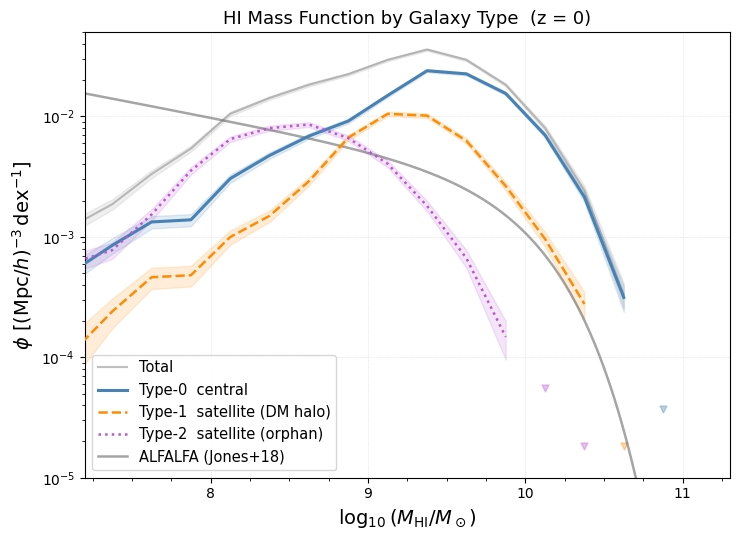

Galaxy type breakdown:
  Type 0 (Type-0  central): 6,419 total, 6,261 with M_HI > 0
  Type 1 (Type-1  satellite (DM halo)): 2,468 total, 2,411 with M_HI > 0
  Type 2 (Type-2  satellite (orphan)): 2,441 total, 2,360 with M_HI > 0


In [5]:
TYPE_STYLES = {
    0: dict(color='steelblue',    lw=2.2, ls='-',  label='Type-0  central'),
    1: dict(color='darkorange',   lw=1.8, ls='--', label='Type-1  satellite (DM halo)'),
    2: dict(color='mediumorchid', lw=1.8, ls=':',  label='Type-2  satellite (orphan)'),
}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# total HIMF (background)
c_tot, p_tot, e_tot, n_tot = mf['HI']
good_tot = n_tot >= N_MIN
ax.fill_between(c_tot[good_tot], p_tot[good_tot] - e_tot[good_tot],
                p_tot[good_tot] + e_tot[good_tot], color='gray', alpha=0.12)
ax.plot(c_tot[good_tot], p_tot[good_tot],
        color='gray', lw=1.5, alpha=0.5, label='Total', zorder=1)

# per-type
for t, style in TYPE_STYLES.items():
    c, p, e, n = mf_type[t]
    good   = n >= N_MIN
    sparse = ~good & (p > 0)
    kw = {k: v for k, v in style.items() if k != 'label'}
    if good.any():
        ax.fill_between(c[good], p[good] - e[good], p[good] + e[good],
                        color=style['color'], alpha=0.15)
        ax.plot(c[good], p[good], **kw, label=style['label'], zorder=4)
    if sparse.any():
        ax.scatter(c[sparse], p[sparse], marker='v', s=25, color=style['color'], alpha=0.35)

# ALFALFA reference
logM_ref = np.linspace(7.0, 11.5, 400)
ax.plot(logM_ref, schechter_mf(logM_ref, ref_alfalfa),
        color='dimgray', lw=1.8, ls='-', alpha=0.6, label='ALFALFA (Jones+18)', zorder=2)

ax.set_yscale('log')
ax.set_xlim(7.2, 11.3)
ax.set_ylim(1e-5, 5e-2)
ax.set_xlabel(r'$\log_{10}(M_{\rm HI} / M_\odot)$', fontsize=14)
ax.set_ylabel(r'$\phi\ [(\mathrm{Mpc}/h)^{-3}\,\mathrm{dex}^{-1}]$', fontsize=14)
ax.set_title('HI Mass Function by Galaxy Type  (z = 0)', fontsize=13)
ax.legend(fontsize=10.5, loc='lower left')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.grid(which='major', ls=':', lw=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(str(GALSPECTRA_ROOT / 'figures' / 'himf_by_type.pdf'), bbox_inches='tight')
plt.show()

print('Galaxy type breakdown:')
for t, style in TYPE_STYLES.items():
    n_total = (gal_type == t).sum()
    n_hi    = mask_HI[gal_type == t].sum()
    print(f'  Type {t} ({style["label"]}): {n_total:,} total, {n_hi:,} with M_HI > 0')

## 5. H₂ and total cold gas mass functions

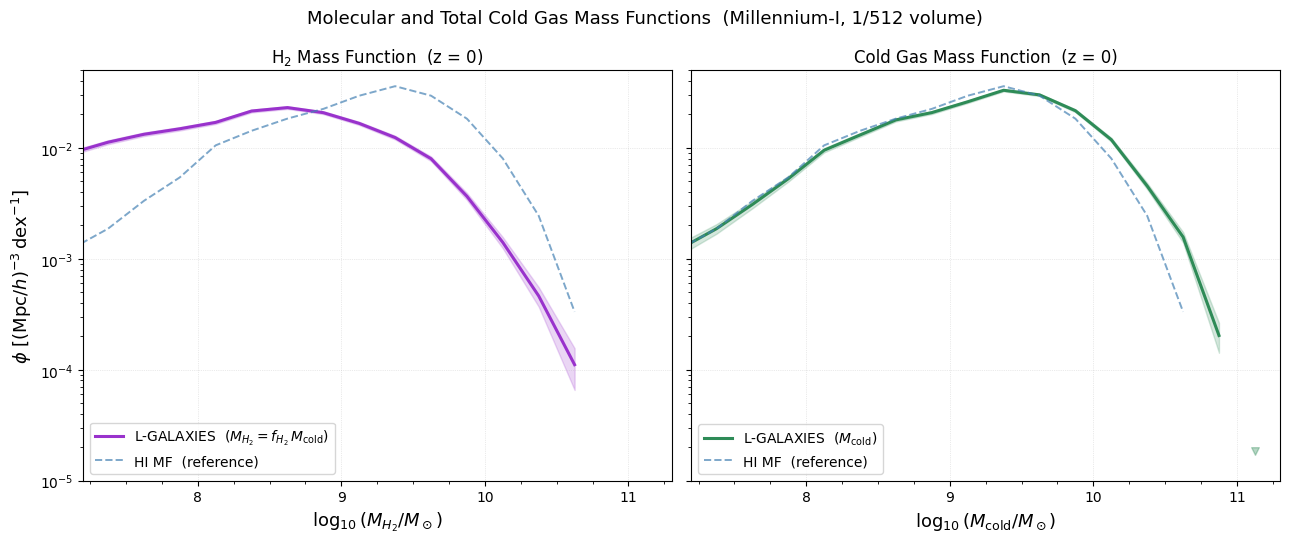

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

PANEL_CFG = [
    ('H2',   axes[0], 'darkorchid',
     r'$M_{H_2} = f_{H_2}\,M_{\rm cold}$',
     r'$\log_{10}(M_{H_2} / M_\odot)$',
     'H$_2$ Mass Function  (z = 0)'),
    ('cold', axes[1], 'seagreen',
     r'$M_{\rm cold}$',
     r'$\log_{10}(M_{\rm cold} / M_\odot)$',
     'Cold Gas Mass Function  (z = 0)'),
]

for key, ax, color, expr, xlabel, title in PANEL_CFG:
    c, p, e, n = mf[key]
    good   = n >= N_MIN
    sparse = ~good & (p > 0)

    ax.fill_between(c[good], p[good] - e[good], p[good] + e[good],
                    color=color, alpha=0.20)
    ax.plot(c[good], p[good], color=color, lw=2.2, label=f'L-GALAXIES  ({expr})')
    if sparse.any():
        ax.scatter(c[sparse], p[sparse], marker='v', s=30, color=color, alpha=0.35)

    # HI MF overplotted for reference
    c_hi, p_hi, _, n_hi = mf['HI']
    ax.plot(c_hi[n_hi >= N_MIN], p_hi[n_hi >= N_MIN],
            color='steelblue', lw=1.4, ls='--', alpha=0.7, label='HI MF  (reference)')

    ax.set_yscale('log')
    ax.set_xlim(7.2, 11.3)
    ax.set_ylim(1e-5, 5e-2)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_title(title, fontsize=12)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.grid(which='major', ls=':', lw=0.5, alpha=0.5)
    ax.legend(fontsize=10)

axes[0].set_ylabel(r'$\phi\ [(\mathrm{Mpc}/h)^{-3}\,\mathrm{dex}^{-1}]$', fontsize=13)
fig.suptitle('Molecular and Total Cold Gas Mass Functions  (Millennium-I, 1/512 volume)', fontsize=13)

plt.tight_layout()
plt.savefig(str(GALSPECTRA_ROOT / 'figures' / 'h2_coldgas_mf.pdf'), bbox_inches='tight')
plt.show()

## 6. Summary statistics

In [7]:
def integrated_density(centres, phi, counts, logm_lo=8.5, logm_hi=11.5):
    dlogM = LOGM_BINS[1] - LOGM_BINS[0]
    mask  = (centres >= logm_lo) & (centres <= logm_hi) & (counts >= N_MIN)
    return np.sum(phi[mask]) * dlogM


def peak_logM(centres, phi, counts):
    mask = counts >= N_MIN
    if not mask.any():
        return np.nan, np.nan
    idx = np.argmax(phi[mask])
    return centres[mask][idx], phi[mask][idx]


sep = '-' * 78
print(sep)
print(f'{"Mass function":<28}  {"Peak log10 M":>12}  {"phi_peak":>12}  {"int phi dlogM [8.5,11.5]":>24}')
print(sep)

LABELS = {
    'HI'  : 'HI  (1-f_H2) x M_cold',
    'H2'  : 'H2  f_H2 x M_cold',
    'cold': 'Cold gas total',
}
for key, label in LABELS.items():
    c, p, e, n = mf[key]
    pk, phipk  = peak_logM(c, p, n)
    intd       = integrated_density(c, p, n)
    print(f'{label:<28}  {pk:>12.2f}  {phipk:>12.4e}  {intd:>24.4e}')

print(sep)
print()

# ── comparison table at selected masses ──────────────────────────────────────
print('Comparison at selected log10(M_HI) values:')
header = f'{"log10 M":>8}'
for name in REFERENCES:
    header += f'  {name[:20]:>22}'
header += f'  {"L-GALAXIES":>14}'
print(header)

c_hi, p_hi, _, n_hi = mf['HI']
for logm in [8.5, 9.0, 9.5, 10.0, 10.5]:
    row = f'{logm:>8.1f}'
    for p_dict in REFERENCES.values():
        row += f'  {schechter_mf(logm, p_dict):>22.4e}'
    idx     = np.argmin(np.abs(c_hi - logm))
    sim_val = p_hi[idx] if n_hi[idx] >= N_MIN else float('nan')
    row += f'  {sim_val:>14.4e}'
    print(row)

------------------------------------------------------------------------------
Mass function                 Peak log10 M      phi_peak  int phi dlogM [8.5,11.5]
------------------------------------------------------------------------------
HI  (1-f_H2) x M_cold                 9.38    3.5974e-02                4.1243e-02
H2  f_H2 x M_cold                     8.62    2.3071e-02                2.1615e-02
Cold gas total                        9.38    3.3053e-02                4.1899e-02
------------------------------------------------------------------------------

Comparison at selected log10(M_HI) values:
 log10 M      ALFALFA (Jones+18)       HIPASS (Zwaan+05)      L-GALAXIES
     8.5              7.1357e-03              1.3140e-02      1.4253e-02
     9.0              4.9765e-03              7.8490e-03      2.2461e-02
     9.5              2.9666e-03              3.8653e-03      3.5974e-02
    10.0              1.0767e-03              1.0337e-03      1.8320e-02
    10.5              